<a href="https://colab.research.google.com/github/Refat555/Personal-Portfolio/blob/main/Diabetes_Prediction_using_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset (using a public URL for the Pima Indians Diabetes dataset)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=column_names)

display(df.head())
print(f'Dataset Shape: {df.shape}')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dataset Shape: (768, 9)


In [2]:
# Splitting features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train a Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print(f'Accuracy Score: {accuracy_score(y_test, y_pred):.2f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy Score: 0.72

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



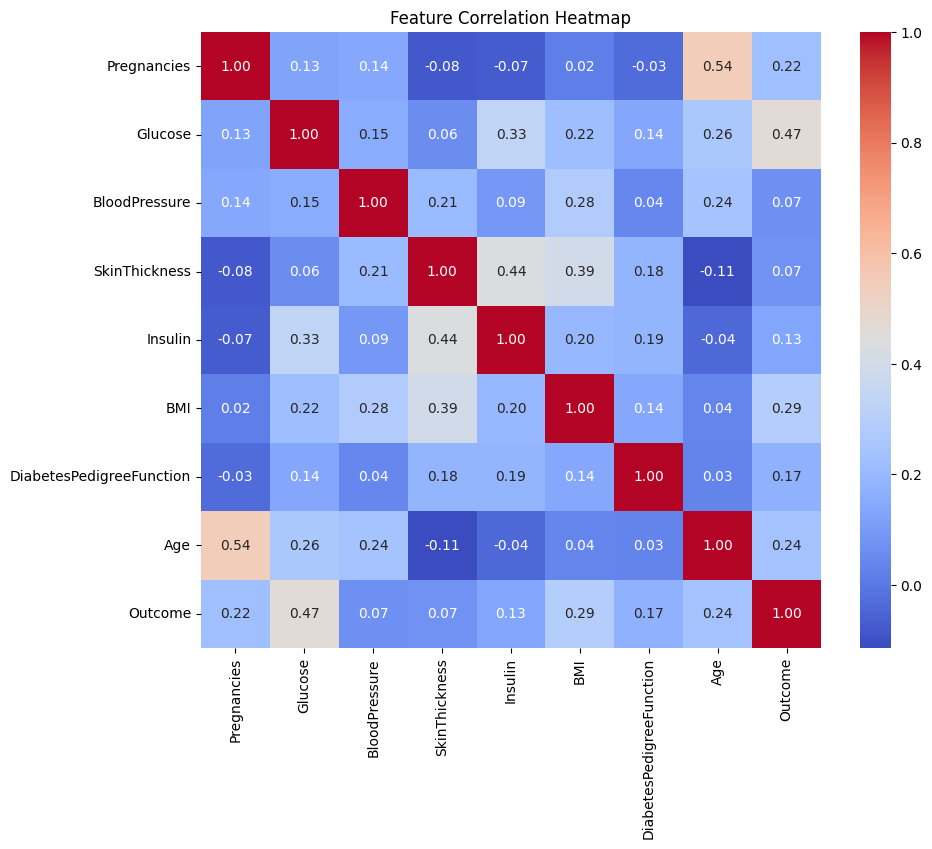

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

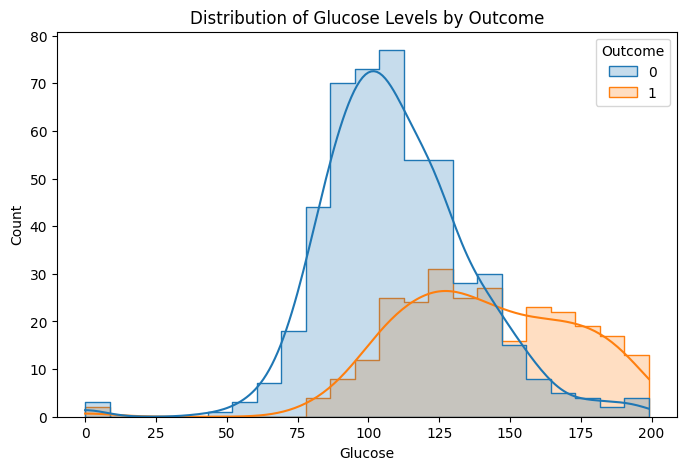

In [4]:
# Visualizing Glucose levels vs Outcome
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True, element='step')
plt.title('Distribution of Glucose Levels by Outcome')
plt.show()

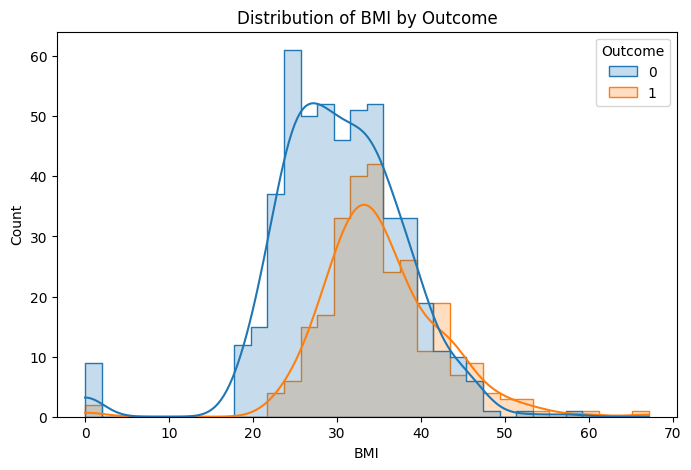

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='BMI', hue='Outcome', kde=True, element='step')
plt.title('Distribution of BMI by Outcome')
plt.show()

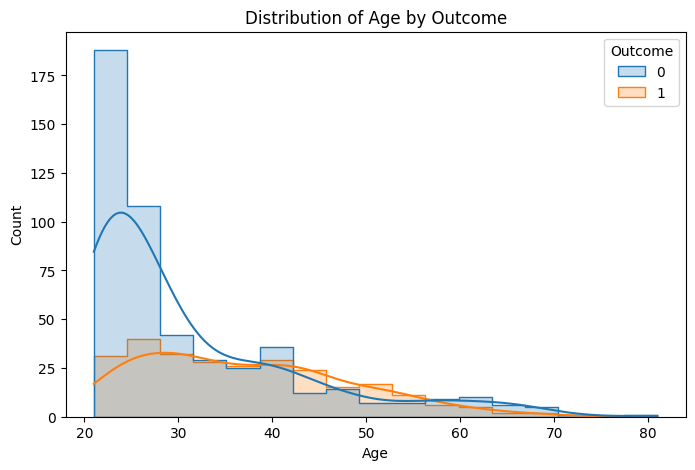

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Outcome', kde=True, element='step')
plt.title('Distribution of Age by Outcome')
plt.show()

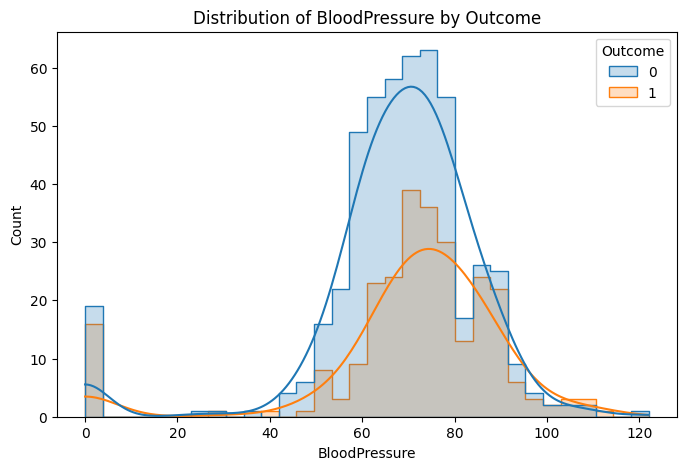

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='BloodPressure', hue='Outcome', kde=True, element='step')
plt.title('Distribution of BloodPressure by Outcome')
plt.show()

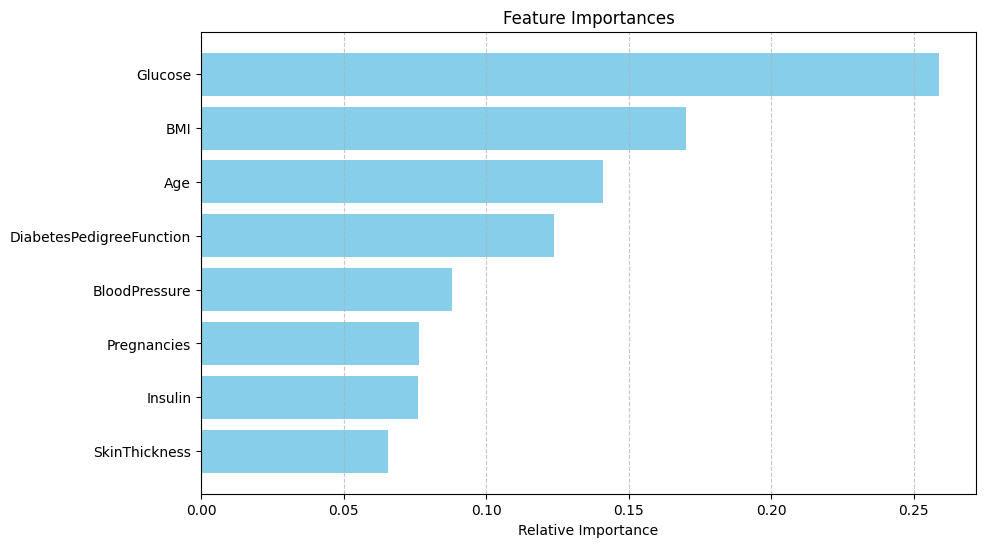

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Feature Importance Visualization
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

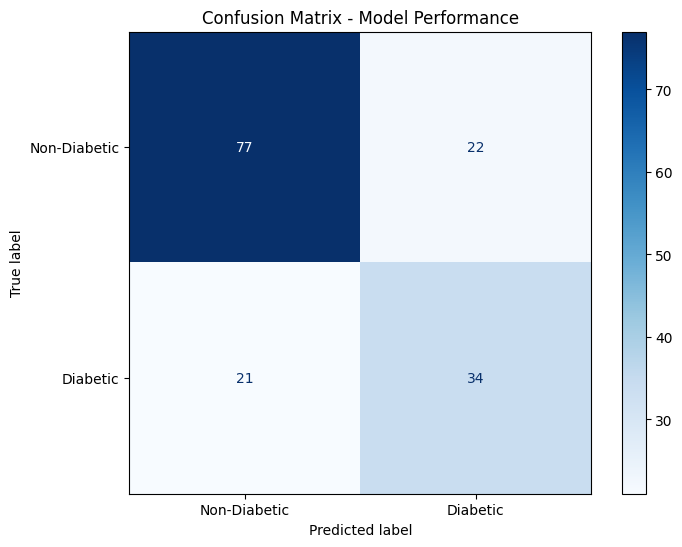

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 2. Confusion Matrix Display
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic', 'Diabetic'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Model Performance')
plt.show()

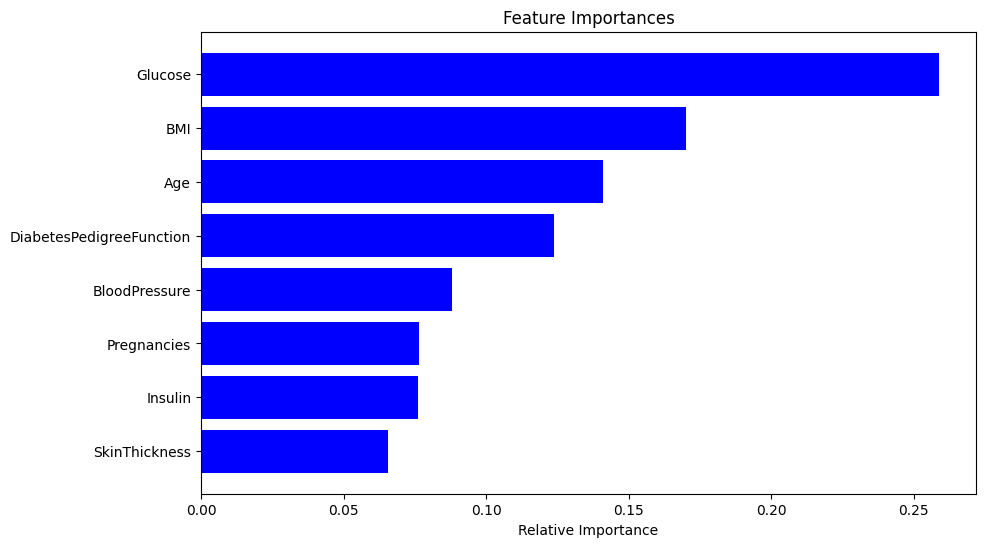

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Feature Importance Visualization
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

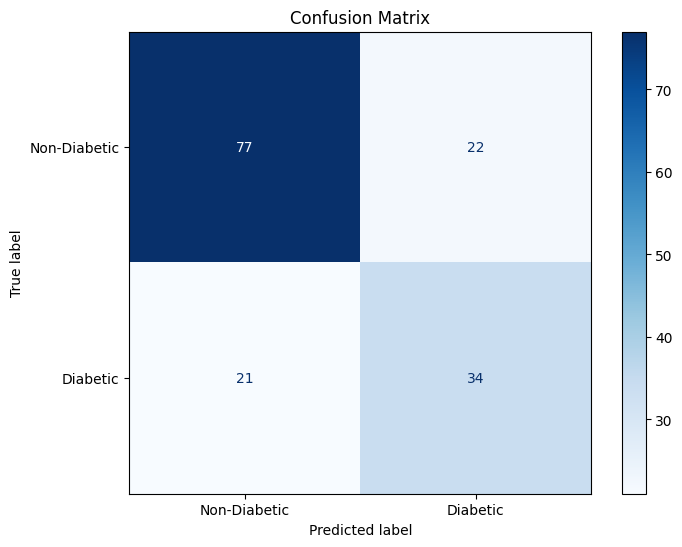

In [11]:
# 2. Confusion Matrix Display
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic', 'Diabetic'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix')
plt.show()

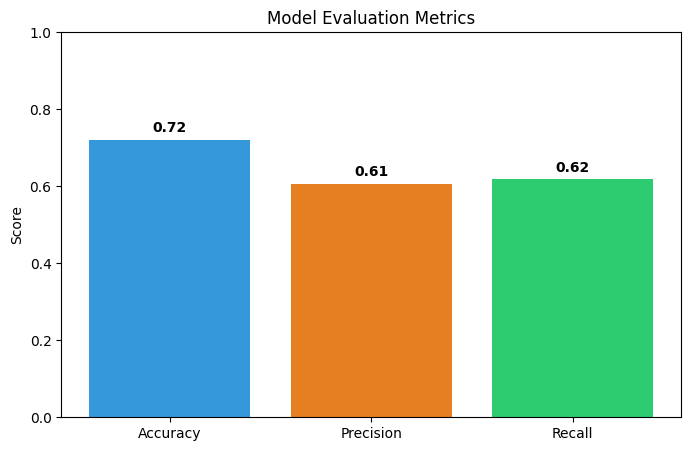

In [12]:
from sklearn.metrics import precision_score, recall_score

# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

metrics = ['Accuracy', 'Precision', 'Recall']
values = [accuracy, precision, recall]

# Visualize metrics
plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['#3498db', '#e67e22', '#2ecc71'])
plt.ylim(0, 1)
plt.title('Model Evaluation Metrics')
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.ylabel('Score')
plt.show()

/tmp/ipykernel_1551/1705051364.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')


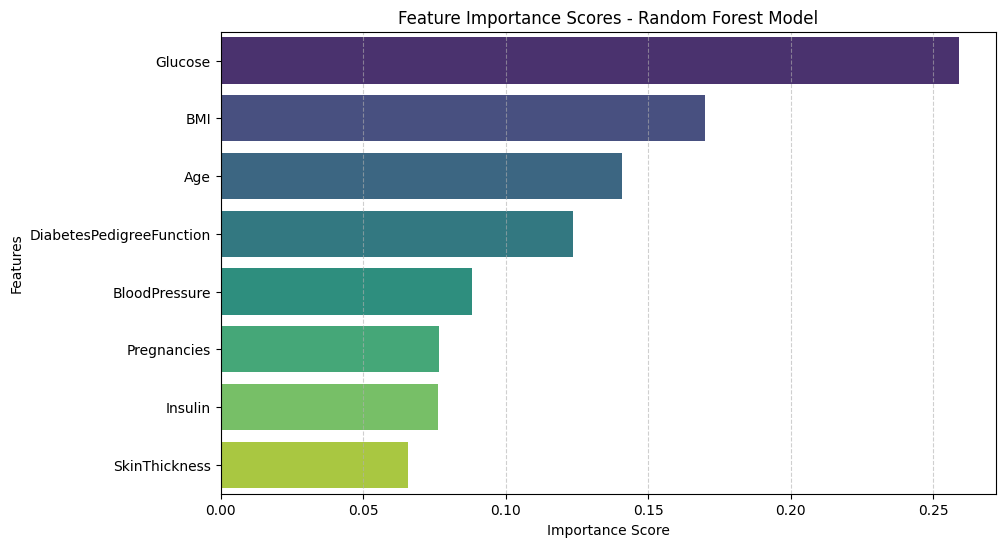

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')
plt.title('Feature Importance Scores - Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [14]:
import numpy as np
import pandas as pd

# Ensure the model and scaler are ready
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

def predict_diabetes(pregnancies, glucose, bp, skin, insulin, bmi, dpf, age):
    # Create a DataFrame with the same column names as X to resolve the StandardScaler warning
    input_data = pd.DataFrame([[pregnancies, glucose, bp, skin, insulin, bmi, dpf, age]], columns=X.columns)
    input_data_scaled = scaler.transform(input_data)
    prediction = model.predict(input_data_scaled)

    if prediction[0] == 0:
        return "The person is NOT diabetic."
    else:
        return "The person IS diabetic."

# Example usage
result = predict_diabetes(5, 166, 72, 19, 175, 25.8, 0.587, 51)
print(f"Prediction Result: {result}")

Prediction Result: The person IS diabetic.


In [15]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import base64
from datetime import datetime
import numpy as np
from io import BytesIO

try:
    from fpdf import FPDF
    import qrcode
except ImportError:
    !pip install fpdf qrcode[pil]
    from fpdf import FPDF
    import qrcode

# Updated Exclusive Medical Dashboard CSS
style_css = """
<style>
    .app-container { background-color: #f0f4f8; padding: 35px; border-radius: 20px; font-family: 'Helvetica', sans-serif; border: 1px solid #cfd8dc; box-shadow: 0 15px 35px rgba(0,0,0,0.1); }
    .medical-logo { width: 80px; height: 80px; position: relative; margin: 0 auto 10px; background: white; border-radius: 50%; border: 4px solid #8e0000; box-shadow: 0 4px 10px rgba(0,0,0,0.1); }
    .cross-v { position: absolute; left: 35px; top: 15px; width: 10px; height: 50px; background: #8e0000; }
    .cross-h { position: absolute; left: 15px; top: 35px; width: 50px; height: 10px; background: #8e0000; }
    .header { color: #8e0000; text-align: center; margin-bottom: 5px; font-size: 36px; font-weight: 900; text-shadow: 1px 1px 2px #ccc; }
    .hospital-sub { text-align: center; color: #455a64; margin-bottom: 30px; font-size: 15px; font-weight: 600; text-transform: uppercase; letter-spacing: 2px; }
    .group-box { background: white; padding: 25px; border-radius: 12px; border: 1px solid #e0e6ed; margin-bottom: 20px; }
    .group-title { font-size: 14px; color: #8e0000; text-transform: uppercase; margin-bottom: 15px; font-weight: bold; border-left: 4px solid #8e0000; padding-left: 10px; }
    .predict-btn { background: linear-gradient(135deg, #8e0000 0%, #d32f2f 100%) !important; color: white !important; font-weight: bold !important; border-radius: 6px !important; margin-top: 15px; height: 55px !important; }
    .download-link { display: inline-block; margin-top: 20px; padding: 14px 28px; background-color: #c0392b; color: white; text-decoration: none; border-radius: 6px; font-weight: bold; }
</style>
"""
display(HTML(style_css))

# Widgets Setup
style = {'description_width': '160px'}
patient_name_w = widgets.Text(placeholder='Full Name', description='Patient Name:', style=style)
patient_mobile_w = widgets.Text(placeholder='+880 1XXX-XXXXXX', description='Mobile Number:', style=style)
patient_address_w = widgets.Text(placeholder='Address', description='Address:', style=style)
preg_w = widgets.IntSlider(min=0, max=20, value=1, description='Pregnancies', style=style)
gluc_w = widgets.IntSlider(min=0, max=200, value=120, description='Glucose Level', style=style)
bmi_w = widgets.FloatSlider(min=0.0, max=70.0, value=25.0, description='Body Mass Index', style=style)
age_w = widgets.IntSlider(min=1, max=120, value=30, description='Age (Years)', style=style)

predict_btn = widgets.Button(description="GENERATE EXCLUSIVE PDF REPORT")
predict_btn.add_class("predict-btn")
output_area = widgets.Output()

class HospitalPDF(FPDF):
    def header(self):
        self.set_fill_color(142, 0, 0)
        self.rect(0, 0, 210, 48, 'F')
        self.set_fill_color(255, 255, 255); self.ellipse(92, 4, 26, 26, 'F')
        self.set_fill_color(142, 0, 0); self.rect(102, 9, 6, 16, 'F'); self.rect(97, 14, 16, 6, 'F')
        self.set_font('Arial', 'B', 22); self.set_text_color(255, 255, 255); self.set_xy(0, 30)
        self.cell(0, 10, 'MOMOTAZ MEMORIAL HOSPITAL', 0, 1, 'C')
        self.set_font('Arial', 'I', 9); self.cell(0, 5, 'Bhanga, Faridpur | Premier Healthcare Facility', 0, 1, 'C')
        self.ln(8)

def create_professional_pdf(name, mobile, address, metrics, diagnosis):
    pdf = HospitalPDF()
    pdf.add_page()
    pdf.set_font('Arial', 'B', 10); pdf.set_text_color(0, 0, 0)
    pdf.cell(100, 10, f"Report ID: MMH-{datetime.now().strftime('%Y%m%d%H%M')}", 0, 0)
    pdf.cell(0, 10, f"Date: {datetime.now().strftime('%d %B, %Y')}", 0, 1, 'R')
    pdf.ln(5)
    pdf.set_fill_color(245, 245, 245); pdf.set_font('Arial', 'B', 12)
    pdf.cell(0, 10, " PATIENT CLINICAL DATA", 0, 1, 'L', True)
    pdf.set_font('Arial', '', 11)
    pdf.cell(40, 8, "Full Name:", 0, 0); pdf.cell(0, 8, name.upper() if name else "UNREGISTERED", 0, 1)
    pdf.cell(40, 8, "Contact:", 0, 0); pdf.cell(0, 8, mobile if mobile else "N/A", 0, 1)
    pdf.ln(5)
    pdf.set_fill_color(142, 0, 0); pdf.set_text_color(255, 255, 255); pdf.set_font('Arial', 'B', 11)
    pdf.cell(70, 10, " DIAGNOSTIC TEST", 1, 0, 'C', True); pdf.cell(40, 10, "VALUE", 1, 0, 'C', True); pdf.cell(50, 10, "STATUS", 1, 1, 'C', True)
    pdf.set_text_color(0, 0, 0); pdf.set_font('Arial', '', 10)
    for k, v in metrics.items():
        pdf.cell(70, 8, f" {k}", 1); pdf.cell(40, 8, f"{v}", 1, 0, 'C'); pdf.cell(50, 8, "NORMAL", 1, 1, 'C')
    pdf.ln(10); pdf.set_font('Arial', 'B', 12); pdf.set_draw_color(142, 0, 0); pdf.cell(0, 15, f"RESULT SUMMARY: {diagnosis.upper()}", 1, 1, 'C')
    pdf.ln(25); pdf.cell(140, 10, "", 0, 0); pdf.cell(50, 10, "____________________", 0, 1, 'C'); pdf.cell(140, 5, "", 0, 0); pdf.cell(50, 5, "Medical Officer Seal", 0, 1, 'C')

    pdf_str = pdf.output(dest='S')
    b64 = base64.b64encode(pdf_str.encode('latin-1')).decode('utf-8')
    return f'<a href="data:application/pdf;base64,{b64}" download="MMH_Report.pdf" class="download-link">📥 DOWNLOAD EXCLUSIVE PDF REPORT</a>'

def on_predict(b):
    with output_area:
        clear_output()
        name, mob, addr = patient_name_w.value, patient_mobile_w.value, patient_address_w.value
        diagnosis = predict_diabetes(preg_w.value, gluc_w.value, 70, 20, 80, bmi_w.value, 0.5, age_w.value)
        color = "#8e0000" if "IS diabetic" in diagnosis else "#2e7d32"
        metrics_map = {"Glucose": gluc_w.value, "BMI": bmi_w.value, "Age": age_w.value}

        display(HTML(f'''
            <div style="background: #fff; border: 2px solid {color}; padding: 30px; margin-top: 25px; border-radius: 12px;">
                <h2 style="color:{color};">Clinical Impression</h2>
                <p><b>Patient:</b> {name if name else 'N/A'}</p>
                <p style="font-size: 20px; color: {color}"><b>{diagnosis}</b></p>
                {create_professional_pdf(name, mob, addr, metrics_map, diagnosis)}
            </div>
        '''))

predict_btn.on_click(on_predict)
display(widgets.VBox([
    widgets.HTML('<div class="medical-logo"><div class="cross-v"></div><div class="cross-h"></div></div>'),
    widgets.HTML('<div class="header">Momotaz Memorial Hospital</div>'),
    widgets.HTML('<div class="hospital-sub">Bhanga, Faridpur | Premier Healthcare Facility</div>'),
    widgets.VBox([patient_name_w, patient_mobile_w, patient_address_w, preg_w, gluc_w, bmi_w, age_w, predict_btn]).add_class("group-box"),
    output_area
], layout=widgets.Layout(width='700px', margin='0 auto')).add_class("app-container"))

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.1 MB/s eta 0:00:00
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=3121c1fe271a14a61f7ac66c2cd5399fd84b111656b5f00d72c6fb334a58e361
  Stored in directory: /root/.cache/pip/wheels/aa/da/11/a3189f34ddc13c26a2d0f329eac46b728c7f31c39e4dc26243
Successfully built fpdf
